In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
CSV_PATH = "Findex_Microdata_2025_updatePakistan.csv"

In [14]:
# 1. Load
# ---------------------------------------------------------------------
df = pd.read_csv(CSV_PATH)
print(f"Loaded {df.shape[0]} rows, {df.shape[1]} columns")

Loaded 1000 rows, 199 columns


In [15]:
# 2. Select feature set
# ---------------------------------------------------------------------
demographics = ["female", "age", "educ", "inc_q", "emp_in", "urbanicity"]
access = ["account", "account_fin", "account_mob", "dig_account", "con1", "internet_use"]
behaviour = ["anydigpayment", "merchantpay_dig", "saved", "fin17b", "fin17c",
             "borrowed", "fin22a", "fin22a_1"]
resilience = ["fin24a", "fin24b"]

selected_cols = demographics + access + behaviour + resilience
missing_cols = [c for c in selected_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Columns not found in data: {missing_cols}")

data = df[selected_cols].copy()

In [16]:
# 3. Recode to consistent 0/1 (Yes=1, No=0), per codebook value labels.
#    Findex uses TWO different coding conventions:
#      - "Constructed" indicators (account, dig_account, saved, borrowed,
#        anydigpayment, merchantpay_dig, internet_use, account_fin,
#        account_mob): already 0/1, 1=Yes. Left as-is.
#      - Raw survey items (fin17b, fin17c, fin22a, fin22a_1, con1):
#        1=Yes, 2=No, 3=DK, 4=Refused. Recoded below: 1->1, else->0.
#    fin17b and fin22a_1 are routed questions (only asked to mobile money
#    account holders) -> ~739 NaN by design, not missing data. Recoded
#    NaN -> 0 (did not do this, since they don't have the account to do
#    it through) rather than dropped, so no rows are lost.
# ---------------------------------------------------------------------
already_binary = ["account", "account_fin", "account_mob", "dig_account",
                   "borrowed", "saved", "anydigpayment", "merchantpay_dig",
                   "internet_use"]

raw_yes_no = ["fin17b", "fin17c", "fin22a", "fin22a_1", "con1"]
for col in raw_yes_no:
    data[col] = (data[col] == 1).astype(int)  # 1=Yes -> 1; 2/3/4/NaN -> 0

# female: 1=Female, 2=Male -> is_female 1/0
data["female"] = (data["female"] == 1).astype(int)

# urbanicity: 1=Rural, 2=Urban -> is_rural 1/0
data["urbanicity"] = (data["urbanicity"] == 1).astype(int)
data.rename(columns={"urbanicity": "is_rural"}, inplace=True)

# emp_in: 1=In workforce, 2=Out -> in_workforce 1/0
data["emp_in"] = (data["emp_in"] == 1).astype(int)
data.rename(columns={"emp_in": "in_workforce"}, inplace=True)

# educ: 1=Primary or less, 2=Secondary, 3=Tertiary+ (1 Sysmiss row, impute mode)
data["educ"] = data["educ"].fillna(data["educ"].mode()[0]).astype(int)

# fin24a: 1=Very difficult .. 3=Not difficult at all, 4/5=DK/Refused,
# NaN=routed out (140 respondents skipped). Keep ordinal 1-3, recode
# DK/Refused/routed as a separate "not asked / unknown" category (0)
# rather than imputing a difficulty level.
data["fin24a"] = data["fin24a"].apply(lambda v: v if v in [1, 2, 3] else 0).astype(int)

# fin24b: 1=<2wks .. 4=>2 months (ordinal), 5/6=DK/Refused -> 0 (unknown)
data["fin24b"] = data["fin24b"].apply(lambda v: v if v in [1, 2, 3, 4] else 0).astype(int)

print("\nPost-recode missingness check:")
print(data.isna().sum().sum(), "total NaNs remaining")


Post-recode missingness check:
0 total NaNs remaining


In [17]:
# 4. Construct Adoption Tier target (non-overlapping definition)
#    Uses only genuinely distinct behaviours to avoid the double-count
#    problem: account type flags (fin/mob/dig) are different lenses on
#    the SAME account and are not treated as separate "products".
# ---------------------------------------------------------------------
def adoption_tier(row):
    has_account = row["account"] == 1
    is_digital = (row["dig_account"] == 1) or (row["anydigpayment"] == 1)
    formal_save_or_borrow = (row["saved"] == 1) or (row["fin22a"] == 1)

    if not has_account:
        return 0  # Excluded
    if not is_digital:
        return 1  # Basic: has account, no digital usage
    if is_digital and formal_save_or_borrow:
        return 3  # Advanced: digital usage + formal saving/borrowing
    return 2  # Digitally Engaged: digital usage, no formal saving/borrowing

data["adoption_tier"] = data.apply(adoption_tier, axis=1)

tier_labels = {0: "Excluded", 1: "Basic", 2: "Digitally Engaged", 3: "Advanced"}
data["adoption_tier_label"] = data["adoption_tier"].map(tier_labels)

print("\nAdoption Tier distribution:")
counts = data["adoption_tier"].value_counts().sort_index()
pct = (data["adoption_tier"].value_counts(normalize=True).sort_index() * 100).round(1)
print(pd.DataFrame({"count": counts, "pct": pct}))


Adoption Tier distribution:
               count   pct
adoption_tier             
0                682  68.2
1                 21   2.1
2                101  10.1
3                196  19.6


In [18]:
# 5. H1 preview: access-usage gap size
# ---------------------------------------------------------------------
account_holders = data[data["account"] == 1]
dormant = ((account_holders["dig_account"] == 0) & (account_holders["anydigpayment"] == 0)).sum()
total_account_holders = len(account_holders)
print(f"\nH1 preview - 'dormant account' segment: {dormant} of {total_account_holders} "
      f"account holders ({100*dormant/total_account_holders:.1f}%) show no digital usage.")



H1 preview - 'dormant account' segment: 21 of 318 account holders (6.6%) show no digital usage.



Saved: adoption_tier_overview.png


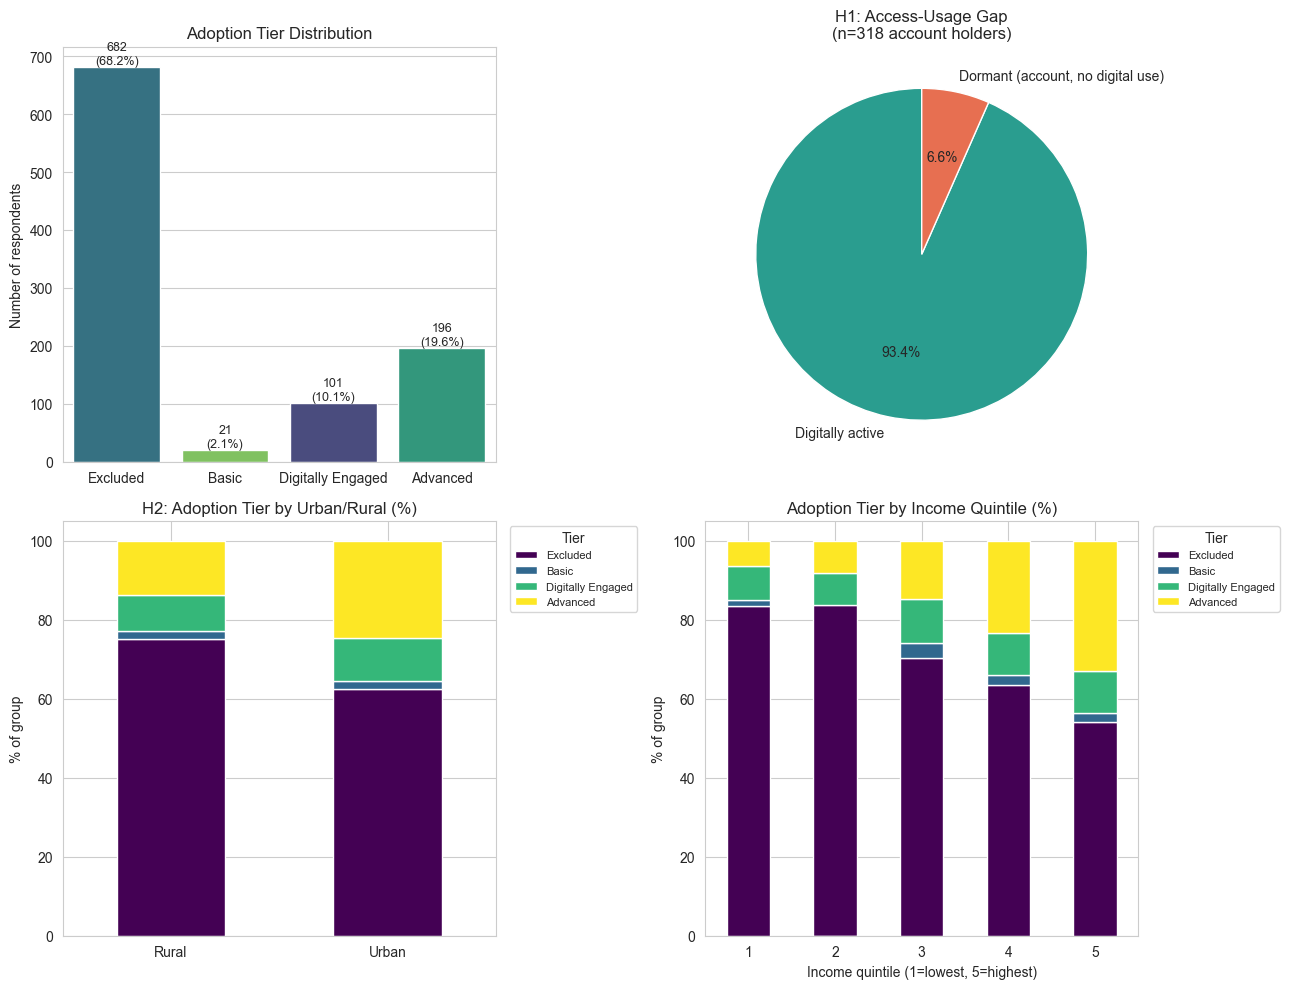

In [19]:
# 6. Visualizations
# ---------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# 6a. Adoption Tier distribution
tier_order = ["Excluded", "Basic", "Digitally Engaged", "Advanced"]
sns.countplot(data=data, x="adoption_tier_label", order=tier_order,
              hue="adoption_tier_label", palette="viridis", legend=False, ax=axes[0, 0])
axes[0, 0].set_title("Adoption Tier Distribution")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Number of respondents")
for p in axes[0, 0].patches:
    h = p.get_height()
    axes[0, 0].annotate(f"{int(h)}\n({100*h/len(data):.1f}%)",
                         (p.get_x() + p.get_width() / 2, h),
                         ha="center", va="bottom", fontsize=9)

# 6b. H1: access-usage gap (account holders only, digital vs dormant)
gap_data = pd.Series({
    "Digitally active": total_account_holders - dormant,
    "Dormant (account, no digital use)": dormant
})
axes[0, 1].pie(gap_data, labels=gap_data.index, autopct="%1.1f%%",
               colors=["#2a9d8f", "#e76f51"], startangle=90)
axes[0, 1].set_title(f"H1: Access-Usage Gap\n(n={total_account_holders} account holders)")

# 6c. H2: Adoption Tier by urban/rural
rural_labels = data["is_rural"].map({1: "Rural", 0: "Urban"})
tier_by_area = pd.crosstab(rural_labels, data["adoption_tier_label"], normalize="index")[tier_order] * 100
tier_by_area.plot(kind="bar", stacked=True, colormap="viridis", ax=axes[1, 0])
axes[1, 0].set_title("H2: Adoption Tier by Urban/Rural (%)")
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("% of group")
axes[1, 0].legend(title="Tier", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
axes[1, 0].tick_params(axis="x", rotation=0)

# 6d. Adoption Tier by income quintile
tier_by_inc = pd.crosstab(data["inc_q"], data["adoption_tier_label"], normalize="index")[tier_order] * 100
tier_by_inc.plot(kind="bar", stacked=True, colormap="viridis", ax=axes[1, 1])
axes[1, 1].set_title("Adoption Tier by Income Quintile (%)")
axes[1, 1].set_xlabel("Income quintile (1=lowest, 5=highest)")
axes[1, 1].set_ylabel("% of group")
axes[1, 1].legend(title="Tier", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
axes[1, 1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("adoption_tier_overview.png", dpi=150, bbox_inches="tight")
print("\nSaved: adoption_tier_overview.png")
plt.show()

Saved: driver_preview.png


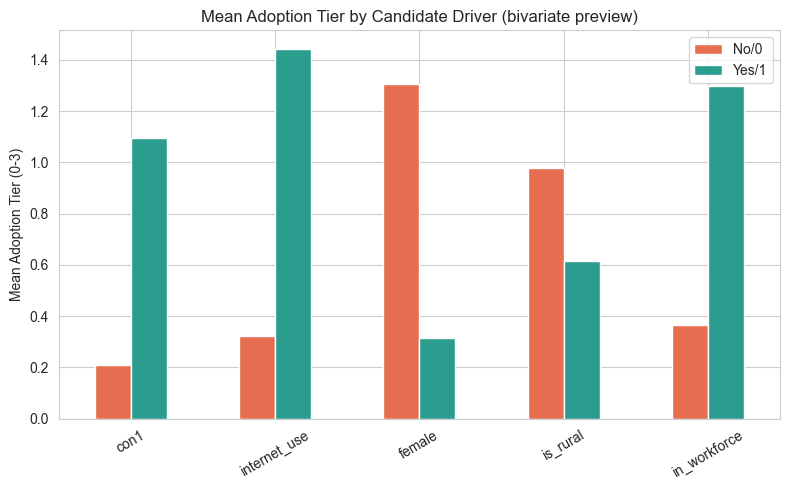

In [20]:
# 7. H3 preview: simple bivariate view of top candidate drivers
#    (Full driver ranking comes later via SHAP in Week 2 modelling.)
# ---------------------------------------------------------------------
driver_candidates = ["con1", "internet_use", "female", "is_rural", "in_workforce"]
fig2, ax2 = plt.subplots(figsize=(8, 5))
mean_tier_by_driver = {}
for col in driver_candidates:
    mean_tier_by_driver[col] = data.groupby(col)["adoption_tier"].mean()
driver_df = pd.DataFrame(mean_tier_by_driver)
driver_df.index = ["No/0", "Yes/1"]
driver_df.T.plot(kind="bar", ax=ax2, color=["#e76f51", "#2a9d8f"])
ax2.set_title("Mean Adoption Tier by Candidate Driver (bivariate preview)")
ax2.set_ylabel("Mean Adoption Tier (0-3)")
ax2.legend(title="")
ax2.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig("driver_preview.png", dpi=150, bbox_inches="tight")
print("Saved: driver_preview.png")
plt.show()

In [21]:
# 8. Save cleaned dataset for Week 2 modelling
# ---------------------------------------------------------------------
data.to_csv("findex_pakistan_features_target.csv", index=False)
print("\nSaved: findex_pakistan_features_target.csv")


Saved: findex_pakistan_features_target.csv
